# Homework - Categorization and Model Comparison Part B (35/105 points)

PSY/COS 360, Computational Models of Cognition, Fall 2026.

Credit for first version and for the categorization data: Prof. Todd Gureckis at New York University.

<div style="background-color: #eef2f6; color: #1f2933; border-left: 4px solid #7b8a97; padding: 12px 16px; border-radius: 4px;">

<p style="margin-top: 0;">Parts of your code are checked by an automated grader. For the grader to work, please keep the following in mind as you complete the assignment:</p>

<ul style="margin-bottom: 0;">
<li><b>Do not rename this notebook file or any of the starter functions we provide.</b> The grader looks for them by name, so a renamed file or function will fail even if the code is correct.</li>
<li><b>Make sure the notebook runs from top to bottom without errors.</b> Before submitting, choose <code>Restart</code>, <code>Clear All Outputs</code>, and then <code>Run All</code> from the notebook menu. Confirm that every cell executes in order and produces the expected output.</li>
<li><b>Do NOT clear the output when submitting.</b> Submit the notebook with the output of each cell. The grader may use these values.</li>
</ul>
</div>


---

In [8]:
import seaborn as sns
import pandas as pd
import math
from scipy.special import comb  # gets the combinations function
from exemplarproto import *  # this grabs much of the code from Part A of the homework
# note that , Part B runs the frozen copy in exemplarproto.py, not your edited Part A cells

## Fitting the models using maximum likelihood

RMSE is not always an ideal mechanism for fitting models.  One reason is that it is insensitive to the number of observations that define each data point.  For example, remember in our experiment that participants saw the prototype item four times at test.  In contrast, there were 20 different "new" patterns.  This means there are five times as many trials contributing to the "new" bar in this graph as for the prototype patterns.  Since RMSE measures the raw deviation of the average model predictions from those of the model it doesn't take into account these issues.  Thus, we would like to also evaluate these two models using maximum likelihood.

The key to this is going to be the provided function below which computes the likelihood of a particular set of data under a binomial probability model. Again, this uses the Pandas library, with a [short introduction here](https://pandas.pydata.org/docs/user_guide/10min.html) and an explanation of the [.groupby](https://pandas.pydata.org/docs/user_guide/groupby.html) routine.

In [9]:
################################
# computeLogLikelihood
# N = number of observations
# S = number of "successes" (i.e., endorsements)
# p = predicted probability of successes by the model
################################
def computeLogLikelihood(N, S, p):
    p = p if p > 0.0 else 0.0+1e-10
    p = p if p < 1.0 else 1.0-1e-10
    try:
        result = math.log(comb(N, S)) + (S*math.log(p) + (N-S)*math.log(1.0-p)) # log binomial likelihood
    except:
        print(N, S, p)  # this shouldn't happen but just in case
        result = float('-inf')
    return result


def pandas_ll(row):
    return computeLogLikelihood(row['Total'], row['N_Yes'], row['Probability of Endorsement'])

A short explanation may be in order: the models predictions take the form of probabilities of endorsement for each of the prototype, low, high, random, and old items. If you find out that people endorse the prototype on 2 out of 2 trials how likely is this outcome given that the model (for a particular set of parameters ) predicts an endorsement of p=0.8? Three numbers are required to do this for each data point N, the number of trials/presentations within the stimulus class, S the number of successes observed (S<=N), and p the predicted probability. Then you can turn the crank on the above `computeLogLikelihood()` function which returns the probability that you would get $S$ successes in $N$ trials if the true probability was $p$ (make sure you understand what is happening in `computeLogLikelihood`). You can sum these log likelihoods for each stimulus class (prototype, low, high, random, old) to compute a total log(likelihood) of the data for any given model with any set of parameters.   For this homework will we focus on fitting the group data rather than to individuals.

To get the data formatted into an appropriate shape for fitting likelihoods we provide a function `get_human_results_ll()` which returns a Pandas data frame containing the number of times a pattern of a particular type was endorsed and the number of times it was presented for each subject.

In [4]:
human_res=get_human_results_ll()
human_res

,Subject,Condition,Stimulus Type,N_Yes,Total
0,./data/8.dat,cat,Prototype,4,4
1,./data/8.dat,cat,Low,4,4
2,./data/8.dat,cat,High,10,10
3,./data/8.dat,cat,Random,15,20
4,./data/8.dat,cat,Old,20,20
...,...,...,...,...,...
0,./data/7.dat,rec,Prototype,3,4
1,./data/7.dat,rec,Low,4,4
2,./data/7.dat,rec,High,8,10
3,./data/7.dat,rec,Random,0,20


This reorganizes the data per condition.

In [10]:
human_data=human_res.groupby(['Condition','Stimulus Type']).sum(numeric_only=True)
human_data

N_Yes  Total
Condition Stimulus Type              
cat       High              49     70
          Low               26     28
          Old              110    140
          Prototype         25     28
          Random            37    140
rec       High              20     70
          Low               16     28
          Old               89    140
          Prototype         18     28
          Random             7    140

Finally these function allow us to compute the negative log likelihood of the data given the model.

In [11]:
def fit_exemplar_model_nll(params, human_results):
    [c_cat, k_cat, c_rec, k_rec] = params
    k_cat = k_cat if k_cat > 0.0 else 0.0
    k_rec = k_rec if k_rec > 0.0 else 0.0
    predictions = get_exemplar_results(c_cat, k_cat, c_rec, k_rec)
    model = predictions.groupby(
        ['Condition', 'Stimulus Type'], as_index=False).mean(numeric_only=True)
    fitted_data = pd.merge(model, human_results)
    return -1.0*fitted_data.apply(pandas_ll, axis=1).sum()


def fit_prototype_model_nll(params, human_results):
    [c_cat, k_cat, c_rec, k_rec] = params
    k_cat = k_cat if k_cat > 0.0 else 0.0
    k_rec = k_rec if k_rec > 0.0 else 0.0
    predictions = get_prototype_results(c_cat, k_cat, c_rec, k_rec)
    model = predictions.groupby(
        ['Condition', 'Stimulus Type'], as_index=False).mean(numeric_only=True)
    fitted_data = pd.merge(model, human_results)
    return -1.0*fitted_data.apply(pandas_ll, axis=1).sum()

<div class="alert alert-success" role="alert">
<h3> Problem 6 (20 points) </h3><br>
The cell blocks below allow you to fit the exemplare model and the prototype model to the dataset we considered in Part A of the homework. Make sure you understand and follow the code provided above and in the provided library (exemplarproto.py).  Next, try altering the parameters to minimize the negative log likelihood score using the `fmin` approach form Part 1.  When you think you have found the best fit parameters for both the exemplar and prototype models report your final parameter values along with the plot of the resulting model predictions.In a markdown cell describe which model you believe fits better.  Is this conclusion the same or different from what you considered with RMSE?  If the fit looks different, why?
</div>

In [13]:
## YOUR CODE HERE

from scipy.optimize import fmin

human = human_res.groupby(['Condition', 'Stimulus Type'], as_index =False).sum(numeric_only=True)

param_opt_exemplar, nll_exemplar, *_ = fmin(fit_exemplar_model_nll, [2.0, 0.1, 2.0, 0.5], args=(human,), full_output=True)
param_opt_prototype, nll_prototype, *_ = fmin(fit_prototype_model_nll, [1.6, 0.03, 1.6, 0.15], args=(human,), full_output=True)

print('Exemplar  [c_cat, k_cat, c_rec, k_rec]:', param_opt_exemplar, ' NLL:', nll_exemplar)
print('Prototype [c_cat, k_cat, c_rec, k_rec]:', param_opt_prototype, ' NLL:', nll_prototype)

Optimization terminated successfully.
         Current function value: 28.268922
         Iterations: 102
         Function evaluations: 174
Optimization terminated successfully.
         Current function value: 32.246756
         Iterations: 133
         Function evaluations: 228
Exemplar  [c_cat, k_cat, c_rec, k_rec]: [1.48768841 0.35961975 1.93038241 0.78405044]  NLL: 28.268922118055986
Prototype [c_cat, k_cat, c_rec, k_rec]: [1.58821153 0.03164295 1.87905563 0.08402059]  NLL: 32.246756090463506


**Answer**

Examplar: [c_cat, k_cat, c_rec, k_rec]: [1.48768841 0.35961975 1.93038241 0.78405044]  NLL: 28.268922118055986
Prototype: [c_cat, k_cat, c_rec, k_rec]: [1.58821153 0.03164295 1.87905563 0.08402059]  NLL: 32.246756090463506

We can see that the exemplar model fits better since it has a lower NLL value of $28.27$ compared to $32.25$ from prototype. This gives the parameters of [c_cat, k_cat, c_rec, k_rec]: [1.48768841 0.35961975 1.93038241 0.78405044]. The reason for this is because RMSE compares the average of each bar and counts every bar equally, no matter how many trials the bar is based on. NLL on the other hand uses the counts, so a bar based on 140 trials matters much more than a bar based on 28. The exemplar model's main errors are on the prototype and low bars, which have only 28 trials each, so RMSE is stricter on them but NLL barely does. The prototype model's main errors are in recognition on the old items (140 trials) and high distortions (70 trials) as it can't tell old items from new distortions, since it only stores an average. NLL punishes these errors heavily. So the two statistics rank the models differently because they weigh the same mistakes differently. 

**Exemplar model**

The negative log score is 28.268922118055986


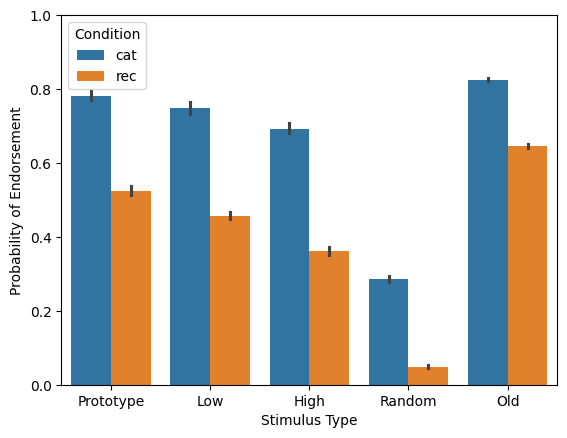

In [14]:
human = human_res.groupby(['Condition', 'Stimulus Type'], as_index=False).sum(numeric_only=True)

params = list(param_opt_exemplar)
nllfit = fit_exemplar_model_nll(params, human)
print(f'The negative log score is {nllfit}')

# now plot the data
c_cat, k_cat, c_rec, k_rec = params
res = get_exemplar_results(c_cat, k_cat, c_rec, k_rec)
ax = sns.barplot(x="Stimulus Type", y="Probability of Endorsement",
            hue="Condition", data=res)
ax.set_ylim(0, 1.0);

**Prototype Model**

The negative log score is 32.246756090463506


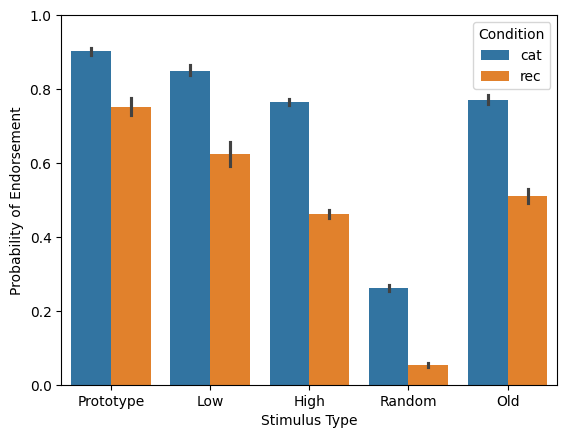

In [15]:
human = human_res.groupby(['Condition', 'Stimulus Type'], as_index=False).sum(numeric_only=True)

params = list(param_opt_prototype)
nllfit = fit_prototype_model_nll(params, human)
print(f'The negative log score is {nllfit}')

# now plot the data
c_cat, k_cat, c_rec, k_rec = params
res = get_prototype_results(c_cat, k_cat, c_rec, k_rec)
ax = sns.barplot(x="Stimulus Type", y="Probability of Endorsement",
            hue="Condition", data=res)
ax.set_ylim(0, 1.0);

**Human data again for reference**

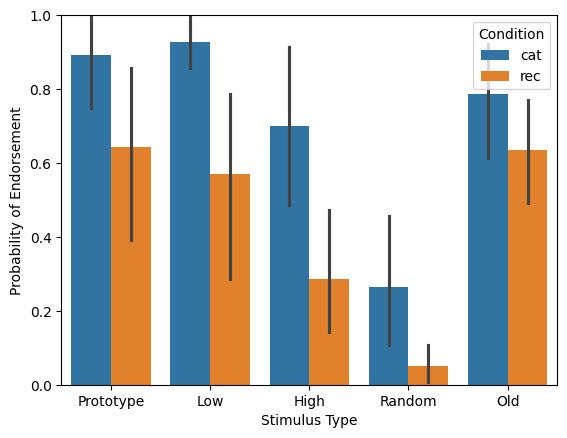

In [16]:
ax = sns.barplot(x="Stimulus Type", y="Probability of Endorsement",
            hue="Condition", data=get_human_results())
ax.set_ylim(0, 1.0);

<div class="alert alert-success" role="alert">
<h3> Problem 7 (10 points) </h3><br>
A famous saying is the "All models are wrong, but some are useful" (George Box).  Do you think the exemplar or prototype model provides the best account of the data?  Refer to particular patterns in the data that you believe the different models do a better job with.
</div>

Overall, I think the exemplar model provides the best single account of the data, but the two models each capture different patterns, which mathces George Box's point that models can be wrong and still useful. The exemplar model's biggest success is the recognition condition. Humans endorsed old items far more than new high distortions in recognition ($0.64$ vs $0.29$), and only the exemplar model can reproduce this since an old item has an exact copy stored in memory ($d=0$), which adds a large $e^0 = 1$ term to the summed similarity. The prototype model  cannot do this as an old item is just another distortion of the average, no more special than a new high distortion so it predicts the two are endorsed about equally. Since old ($140$ trials) and high ($70$ trials) are the most heavily sampled bars, this miss is exactly what maximum likelihood punishes, which is why the exemplar model wins on NLL ($28.27$ vs $32.25$) while the two are nearly tied on RMSE ($0.0768$ vs $0.0778$). However, the prototype model does a better job for categorization as the never-studied prototype was the most endorsed item ($0.89$, even above old items at $0.79$). The prototype model naturally predicts this ordering, since the test prototype is by definition the closest item to the stored average, whereas the exemplar model actually gets this ordering slightly wrong (it predicts old > prototype, because of the exact-copy boost). So the prototype model is still "useful" however it captures the abstraction-like pattern in categorization, while the exemplar model captures the memory-like pattern in recognition. This makes sense since refers from an avereage while the other from a sum. 



<div class="alert alert-success" role="alert">
<h3> Problem 8 (5 points) </h3><br>

Thinking about how these models work explain why both the exemplar and prototype models have relatively high endorsement for the prototype item even though it was never presented during the training phase.  In addition, explain in your own words why the models are able to explain the high endorsement rates for the old items.
    
</div>

Both models give the prototype a high endorsement because all 10 study patterns are distortions of it. Even though the prototype was never shown, it is close to everything in memory. In the exemplar model, each stored pattern is a noisy copy of the prototype. So the prototype is fairly close (small $d_{ij}$) to all 10 stored patterns. No single match is perfect, but all 10 terms in $\sum_j e^{-c \cdot d_{ij}}$ are fairly large, so the total similarity is high. In the prototype model, the noise in the distortions goes in random directions, so it mostly cancels out when the 10 patterns are averaged. The stored average ends up very close to the original prototype. That makes $d_{ip} \approx 0$, so $e^{-c \cdot d_{ip}} \approx 1$. In both cases, the prototype is hidden in the training set, and every study item points toward it. The exemplar model picks up this structure through the sum, and the prototype model picks it up through the average. This matches what people do, since they also infer the common pattern without ever seeing it.